# Chapter 3 (extra): Richtmyer higher-order time stepping

Honeychurch's Chapter 3 improves on the fully implicit (backward-Euler) scheme
not only by *weighting* explicit and implicit operators (Crank–Nicolson,
Douglas; see the main Chapter 3 notebook) but also by replacing the **two-point
backward time derivative** with a **multi-point backward stencil**.

The two-point (first-order) approximation
$$\frac{\partial c}{\partial \tau}\Big|^{k+1}\approx\frac{c^{k+1}-c^{k}}{\Delta\tau}$$
is what makes backward Euler only first-order accurate in time.  Richtmyer's
modification keeps the *spatial* operator fully implicit but uses the **four-step
backward differentiation (BDF4)** stencil for the time derivative:

$$\frac{\partial c}{\partial \tau}\Big|^{k+1}\approx
\frac{1}{\Delta\tau}\left(\tfrac{25}{12}c^{k+1}-4c^{k}+3c^{k-1}
-\tfrac{4}{3}c^{k-2}+\tfrac14 c^{k-3}\right).$$

Discretising Fick's second law $\partial_\tau c=\partial_{xx}c$ with this stencil
on the left and a fully implicit central second difference on the right gives, for
each interior node $j$,

$$-D_M\,c_{j-1}^{k+1}+\Big(\tfrac{25}{12}+2D_M\Big)c_{j}^{k+1}-D_M\,c_{j+1}^{k+1}
=4c_j^k-3c_j^{k-1}+\tfrac43 c_j^{k-2}-\tfrac14 c_j^{k-3},$$

with $D_M = D\,\Delta\tau/\Delta x^2$.  The left-hand side is **tridiagonal with
exactly the same structure as the fully implicit matrix**: only the main diagonal
changes from $1+2D_M$ to $\tfrac{25}{12}+2D_M$.  The right-hand side is a fixed
linear combination of the four previous time levels.

**The startup problem.** The stencil is *backward-looking*: computing $c^{k+1}$
needs $c^k,c^{k-1},c^{k-2},c^{k-3}$.  At the start of the simulation those do not
exist, so the first three steps are taken with the ordinary fully implicit
(backward-Euler) scheme to prime the history. This notebook re-implements the
scheme idiomatically with `serm` helpers, regenerates the accuracy comparison
against the Cottrell transient, and, in the part the book does not make explicit,
**measures the temporal order of convergence**, exposing how the low-order
startup interacts with the high-order interior stencil.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.grids import make_grid, space_points
from serm.tridiagonal import tridiag_solve_banded

np.set_printoptions(precision=5, suppress=True)

In [2]:
from serm.sourcelinks import source_links
source_links(make_grid, space_points, tridiag_solve_banded, serm.cottrell_dimensionless, serm.electrode_current)

## The fully implicit baseline and its bootstrap role

We first need the ordinary fully implicit (backward-Euler) solver for two
reasons: it is the accuracy baseline that Richtmyer is meant to beat, and its
first three steps prime the BDF4 history.

In [3]:
def implicit_solve(D_M, n, m=None):
    """Fully implicit (backward-Euler) solver for the Cottrell potential step.

    Surface c = 0, bulk c = 1, initial c = 1.  Main diagonal 1 + 2 D_M,
    off-diagonals -D_M; the bulk boundary contributes +D_M to the last RHS entry.
    """
    if m is None:
        m = space_points(D_M, n)
    c = make_grid(m, n)
    k_unk = m - 2
    sub = np.full(k_unk - 1, -D_M)
    sup = np.full(k_unk - 1, -D_M)
    diag = np.full(k_unk, 1.0 + 2.0 * D_M)
    for k in range(1, n):
        rhs = c[1:m - 1, k - 1].astype(float).copy()
        rhs[-1] += D_M                       # bulk BC c = 1
        c[1:m - 1, k] = tridiag_solve_banded(sub, diag, sup, rhs)
    return c

## The Richtmyer (BDF4-in-time) solver

The interior matrix differs from the fully implicit one only in the main
diagonal ($\tfrac{25}{12}+2D_M$ instead of $1+2D_M$). Steps $k=1,2,3$ are taken
with the implicit solver; from $k=4$ onward the BDF4 right-hand side
$4c^{k-1}-3c^{k-2}+\tfrac43 c^{k-3}-\tfrac14 c^{k-4}$ is assembled from the stored
history (using 0-based column indices, $c^{k+1}$ is column `k`).

In [4]:
def richtmyer_solve(D_M, n, m=None):
    """Richtmyer BDF4-in-time / fully-implicit-in-space solver.

    Port of richtmyerSolve / solveNext2 from chapter3.nb.  The first three steps
    use the fully implicit scheme to prime the 4-level backward stencil; from the
    fourth step onward the time derivative is the BDF4 combination
    (25/12) c^{k+1} - 4 c^k + 3 c^{k-1} - (4/3) c^{k-2} + (1/4) c^{k-3}.
    """
    if m is None:
        m = space_points(D_M, n)
    # Prime columns 0..3 with the fully implicit scheme.
    c = implicit_solve(D_M, n, m)
    if n <= 4:
        return c
    k_unk = m - 2
    sub = np.full(k_unk - 1, -D_M)
    sup = np.full(k_unk - 1, -D_M)
    diag = np.full(k_unk, 25.0 / 12.0 + 2.0 * D_M)
    for k in range(4, n):
        # BDF4 RHS from the four previous levels c^k, c^{k-1}, c^{k-2}, c^{k-3}.
        temp = (4.0 * c[:, k - 1] - 3.0 * c[:, k - 2]
                + (4.0 / 3.0) * c[:, k - 3] - 0.25 * c[:, k - 4])
        rhs = temp[1:m - 1].astype(float).copy()
        rhs[-1] += D_M                       # bulk BC c = 1
        c[1:m - 1, k] = tridiag_solve_banded(sub, diag, sup, rhs)
    return c

## Accuracy against the Cottrell transient

We run both schemes at $D_M = 1.5$ (where the explicit scheme of Chapter 2 is
unstable) and compare the dimensionless current transient with the analytic
Cottrell result $i(\tau)=1/\sqrt{\pi\tau}$. The Richtmyer scheme is markedly
closer, especially at early times where the step discontinuity stresses the
time integration most.

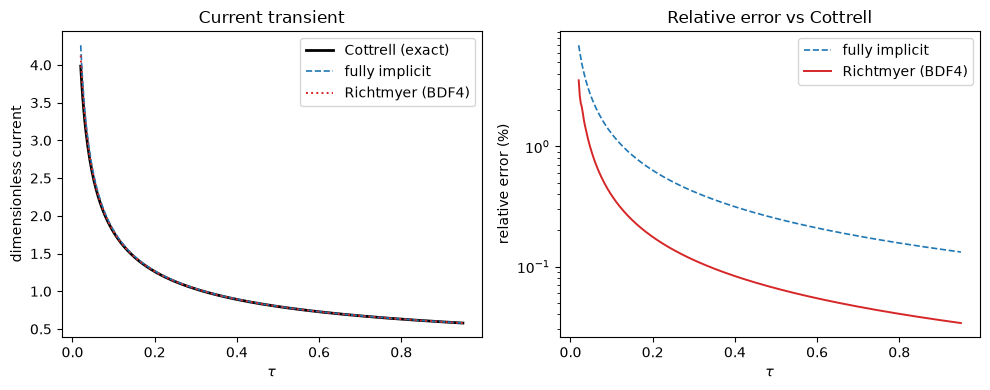

mean relative error  fully implicit : 5.425e-03
mean relative error  Richtmyer       : 1.741e-03
improvement factor                   : 3.12x


In [5]:
D_M = 1.5
n = 400
m = space_points(D_M, n)

c_impl = implicit_solve(D_M, n, m)
c_richt = richtmyer_solve(D_M, n, m)

i_impl = serm.electrode_current(c_impl, D_M)
i_richt = serm.electrode_current(c_richt, D_M)
i_cott = serm.cottrell_dimensionless(n)

tau = np.arange(n) / (n - 1)
win = (tau >= 0.02) & (tau <= 0.95)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.plot(tau[win], i_cott[win], "k-", lw=2, label="Cottrell (exact)")
ax.plot(tau[win], i_impl[win], "C0--", lw=1.2, label="fully implicit")
ax.plot(tau[win], i_richt[win], "C3:", lw=1.4, label="Richtmyer (BDF4)")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("dimensionless current")
ax.set_title("Current transient"); ax.legend()

ax = axes[1]
ax.plot(tau[win], np.abs(i_impl[win] - i_cott[win]) / i_cott[win] * 100,
        "C0--", lw=1.2, label="fully implicit")
ax.plot(tau[win], np.abs(i_richt[win] - i_cott[win]) / i_cott[win] * 100,
        "C3-", lw=1.4, label="Richtmyer (BDF4)")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("relative error (%)")
ax.set_title("Relative error vs Cottrell"); ax.set_yscale("log"); ax.legend()
plt.tight_layout(); plt.show()

mr_impl = float(np.nanmean(np.abs(i_impl[win] - i_cott[win]) / i_cott[win]))
mr_richt = float(np.nanmean(np.abs(i_richt[win] - i_cott[win]) / i_cott[win]))
print(f"mean relative error  fully implicit : {mr_impl:.3e}")
print(f"mean relative error  Richtmyer       : {mr_richt:.3e}")
print(f"improvement factor                   : {mr_impl / mr_richt:.2f}x")

## Temporal order of convergence

The headline reason for the BDF4 stencil is its *order*. To measure it cleanly
we separate the time integration from the spatial discretisation using a
**method of lines**: fix a spatial grid, build the semidiscrete system
$\dot{\mathbf c}=L\mathbf c+\mathbf g$, and integrate it with each time stepper.
The exact-in-time solution $\mathbf c(T)=\mathbf c_s+e^{LT}(\mathbf c_0-\mathbf c_s)$
(with steady state $\mathbf c_s=-L^{-1}\mathbf g$) is the reference, so the only
error left is temporal.

This isolates an important subtlety the book glosses over. The BDF4 *interior*
stencil is fourth-order, but the three backward-Euler **startup** steps are only
first-order. We therefore test two startups:

1. **Exact startup**: prime the history from the analytic reference. This
   reveals the *intrinsic* order of the interior stencil.
2. **Backward-Euler startup**: exactly what `richtmyer_solve` does. This is the
   order you actually get in practice.

In [6]:
from scipy.linalg import expm

def _space_operator(m, dx):
    """Interior Laplacian L (k x k) and BC vector g for dc/dt = L c + g."""
    k = m - 2
    L = (np.diag(np.full(k, -2.0))
         + np.diag(np.ones(k - 1), 1)
         + np.diag(np.ones(k - 1), -1)) / dx**2
    g = np.zeros(k); g[-1] = 1.0 / dx**2     # bulk BC c = 1; surface BC c = 0
    return L, g

m_v, dx_v, T_v = 81, 0.05, 0.5
L, g = _space_operator(m_v, dx_v)
c0 = np.ones(m_v - 2)
c_steady = np.linalg.solve(L, -g)
def exact_in_time(t):
    return c_steady + expm(L * t) @ (c0 - c_steady)
c_ref = exact_in_time(T_v)
I = np.eye(m_v - 2)

def _be_step(c, dt):
    return np.linalg.solve(I - dt * L, c + dt * g)

def integrate_bdf4(N, exact_startup):
    """Method-of-lines BDF4 over N steps; bootstrap exactly or with backward Euler."""
    dt = T_v / N
    if exact_startup:
        hist = [exact_in_time(i * dt) for i in range(4)]
    else:
        hist = [c0.copy()]
        c = c0.copy()
        for _ in range(3):
            c = _be_step(c, dt); hist.append(c.copy())
    A = (25.0 / 12.0) * I - dt * L
    for _ in range(3, N):
        rhs = (4.0 * hist[-1] - 3.0 * hist[-2]
               + (4.0 / 3.0) * hist[-3] - 0.25 * hist[-4] + dt * g)
        hist.append(np.linalg.solve(A, rhs))
    return hist[-1]

def integrate_be(N):
    dt = T_v / N
    c = c0.copy()
    for _ in range(N):
        c = _be_step(c, dt)
    return c

Ns = np.array([40, 80, 160, 320, 640])
dts = T_v / Ns
results = {
    "backward Euler": (np.array([np.max(np.abs(integrate_be(N) - c_ref)) for N in Ns])),
    "BDF4 (exact startup)": np.array([np.max(np.abs(integrate_bdf4(N, True) - c_ref)) for N in Ns]),
    "BDF4 (B-Euler startup)": np.array([np.max(np.abs(integrate_bdf4(N, False) - c_ref)) for N in Ns]),
}
orders = {}
for name, errs in results.items():
    p = np.polyfit(np.log(dts), np.log(errs), 1)[0]
    orders[name] = p
    print(f"{name:24s}: fitted temporal order = {p:.2f}")

backward Euler          : fitted temporal order = 1.00
BDF4 (exact startup)    : fitted temporal order = 4.04
BDF4 (B-Euler startup)  : fitted temporal order = 1.99


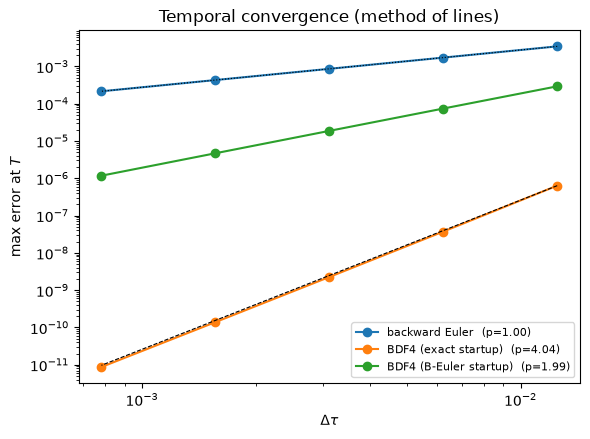

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for name, errs in results.items():
    ax.loglog(dts, errs, "o-", label=f"{name}  (p={orders[name]:.2f})")
# Reference slopes.
ax.loglog(dts, results["backward Euler"][0] * (dts / dts[0])**1, "k:", lw=0.8)
ax.loglog(dts, results["BDF4 (exact startup)"][0] * (dts / dts[0])**4, "k--", lw=0.8)
ax.set_xlabel(r"$\Delta\tau$"); ax.set_ylabel(r"max error at $T$")
ax.set_title("Temporal convergence (method of lines)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**What the plot shows.** Backward Euler converges at first order ($p\approx1$).
The BDF4 interior stencil is genuinely fourth-order ($p\approx4$) when the
startup history is exact. With the backward-Euler bootstrap that the book
actually uses, the global order is limited to $p\approx2$: the low-order startup
error is propagated and dominates. The practical scheme still **doubles the order**
of plain backward Euler and is several times more accurate on the Cottrell test,
which is the real win, but the "higher order" claim only reaches its full
fourth-order potential with a higher-order startup (for example, Crank–Nicolson or a
self-starting Runge–Kutta primer).

## Validation

Three assert-backed checks, strongest first per the project validation policy.

In [8]:
# --- Tier 1: closed-form analytic check (Cottrell) ---
# Both schemes must match the analytic Cottrell transient 1/sqrt(pi tau).
assert mr_impl < 1e-2, mr_impl
assert mr_richt < 1e-2, mr_richt
# --- Richtmyer must beat the fully implicit baseline ---
assert mr_richt < mr_impl, (mr_richt, mr_impl)
print(f"PASS (Tier 1): Richtmyer matches Cottrell to {mr_richt:.2e} mean rel err, "
      f"{mr_impl / mr_richt:.1f}x better than fully implicit.")

# --- Tier 3: temporal order of convergence ---
assert abs(orders["backward Euler"] - 1.0) < 0.15, orders
assert orders["BDF4 (exact startup)"] > 3.5, orders            # genuinely 4th order
assert orders["BDF4 (B-Euler startup)"] > orders["backward Euler"] + 0.7, orders  # strictly higher order
print("PASS (Tier 3): backward Euler ~1st order; BDF4 interior stencil ~4th order "
      "(exact startup); practical BDF4 ~2nd order, strictly above backward Euler.")

PASS (Tier 1): Richtmyer matches Cottrell to 1.74e-03 mean rel err, 3.1x better than fully implicit.
PASS (Tier 3): backward Euler ~1st order; BDF4 interior stencil ~4th order (exact startup); practical BDF4 ~2nd order, strictly above backward Euler.


In [9]:
# --- Tier 2: reduction to a validated limit ---
# At very large n (fine dt) on a fixed grid, the Richtmyer transient must agree
# with the fully implicit one node-for-node late in the simulation (both converge
# to the same diffusion solution). Use a relaxed late-time window.
D_M2, n2 = 1.0, 800
m2 = space_points(D_M2, n2)
ci = implicit_solve(D_M2, n2, m2)
cr = richtmyer_solve(D_M2, n2, m2)
late = slice(int(0.6 * n2), n2)
prof_diff = np.max(np.abs(ci[:, late] - cr[:, late]))
assert prof_diff < 5e-3, prof_diff
print(f"PASS (Tier 2): implicit and Richtmyer concentration profiles agree to "
      f"{prof_diff:.2e} at late times (both recover the same diffusion field).")

PASS (Tier 2): implicit and Richtmyer concentration profiles agree to 2.85e-04 at late times (both recover the same diffusion field).


## Summary

- Richtmyer's modification replaces the two-point backward time derivative with
  the **BDF4** four-level backward stencil, keeping the spatial operator fully
  implicit. Only the main diagonal of the tridiagonal matrix changes
  ($1+2D_M \to \tfrac{25}{12}+2D_M$); the right-hand side becomes a fixed linear
  combination of the previous four time levels.
- It needs a **three-step backward-Euler startup** to prime the history.
- On the Cottrell test it is several times more accurate than plain backward
  Euler at the same grid.
- Its **intrinsic temporal order is 4**, but the low-order startup caps the
  *global* order at approximately 2 in the book's implementation, still double backward
  Euler's first order.

<!-- nav-footer -->

---

[← Chapter 3 — Speed and Accuracy: Implicit and Weighted Finite-Difference Schemes](../03_speed_and_accuracy.ipynb)

[Contents (README)](../../README.md)